C:\Users\user\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



=== 比較実験設定 ===
Time step split: train<= 34, val<= 39, test>= 40
Time step を特徴に含める: False
class weights: [8.0, 1.0]
baseline ratio: 0.0%
compare  ratio: 5.0%
Loading txs_features...
  shape: (203769, 184)

Loading txs_classes...
  shape: (203769, 2)

Loading txs_edgelist...
  shape: (234355, 2)

[baseline_original] unknown の 0.0% を train だけ illicit にする
[baseline_original] injected pseudo-illicit: 0
[baseline_original] split counts: train=29894 val=5486 test=11184
[baseline_original] train class counts: illicit=3462 licit=26432
[baseline_original] val class counts  : illicit=447 licit=5039
[baseline_original] test class counts : illicit=636 licit=10548
[baseline_original] best threshold on val: 0.55
[baseline_original] test metrics: {'threshold': 0.55, 'accuracy': 0.9467989802360535, 'illicit_precision': 0.5420944558521561, 'illicit_recall': 0.41509433962264153, 'illicit_f1': 0.4701691896705254}

[compare_unknown5pct] unknown の 5.0% を train だけ illicit にする
[compare_unknown5pct] injected 

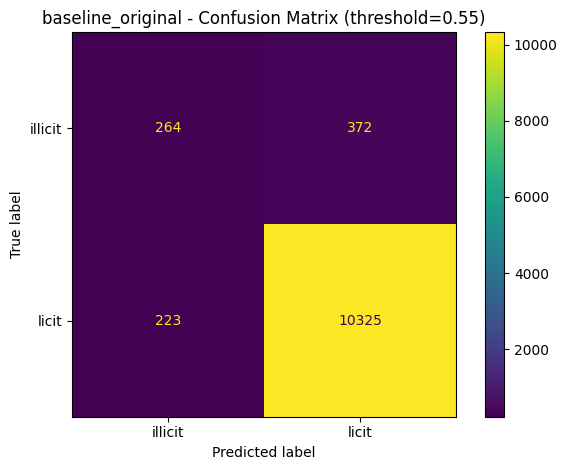


=== baseline_original Classification Report (test only) ===
              precision    recall  f1-score   support

     illicit       0.54      0.42      0.47       636
       licit       0.97      0.98      0.97     10548

    accuracy                           0.95     11184
   macro avg       0.75      0.70      0.72     11184
weighted avg       0.94      0.95      0.94     11184



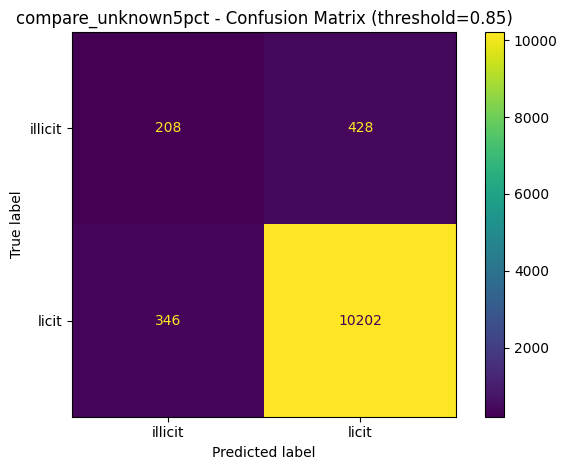


=== compare_unknown5pct Classification Report (test only) ===
              precision    recall  f1-score   support

     illicit       0.38      0.33      0.35       636
       licit       0.96      0.97      0.96     10548

    accuracy                           0.93     11184
   macro avg       0.67      0.65      0.66     11184
weighted avg       0.93      0.93      0.93     11184



In [1]:
"""
Elliptic++ っぽいトランザクショングラフに
GNN（GCN）を適用し、

1) 元のデータ版
   - unknown は unknown のまま
2) 擬似ラベル版
   - train 内 unknown の 5% を illicit に変更

の2条件を同条件で比較する完全版スクリプト。

比較内容
- train / val / test の件数
- best threshold
- test accuracy
- illicit precision / recall / f1
- classification report
- confusion matrix
"""

import copy
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch_geometric.data import Data
from torch_geometric.utils import to_undirected, add_self_loops
from torch_geometric.nn import GCNConv

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    f1_score,
    recall_score,
    precision_score,
)

warnings.filterwarnings("ignore")


# ==========================
# 設定
# ==========================
TXS_FEATURES = "./transactions/txs_features.txt"
TXS_CLASSES  = "./transactions/txs_classes.txt"
TXS_EDGES    = "./transactions/txs_edgelist.txt"

TRAIN_END_STEP = 34
VAL_END_STEP   = 39

HIDDEN_DIM = 64
DROPOUT = 0.5
LR = 1e-3
WEIGHT_DECAY = 5e-4
EPOCHS = 150

CLASS_WEIGHTS = [8.0, 1.0]
INCLUDE_TIME_STEP_AS_FEATURE = False

# 比較対象
BASELINE_UNKNOWN_TO_ILLICIT_RATIO = 0.00
COMPARE_UNKNOWN_TO_ILLICIT_RATIO  = 0.05

THRESHOLD_GRID = np.arange(0.05, 0.96, 0.05)


# ==========================
# ユーティリティ
# ==========================
def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def check_files():
    for path in [TXS_FEATURES, TXS_CLASSES, TXS_EDGES]:
        if not Path(path).exists():
            raise FileNotFoundError(f"ファイルが見つかりません: {path}")


def make_time_based_masks(time_steps, labeled_mask, train_end_step, val_end_step):
    train_mask = (time_steps <= train_end_step) & labeled_mask
    val_mask   = (time_steps > train_end_step) & (time_steps <= val_end_step) & labeled_mask
    test_mask  = (time_steps > val_end_step) & labeled_mask
    return train_mask, val_mask, test_mask


def inject_unknown_as_illicit_by_ratio(
    y_np: np.ndarray,
    time_steps_np: np.ndarray,
    train_end_step: int,
    ratio: float = 0.05,
    seed: int = 42
):
    rng = np.random.default_rng(seed)

    train_unknown_idx = np.where(
        (time_steps_np <= train_end_step) & (y_np == -1)
    )[0]

    n_unknown = len(train_unknown_idx)
    n_pick = int(n_unknown * ratio)

    y_new = y_np.copy()

    if n_unknown == 0 or n_pick == 0:
        return y_new, np.array([], dtype=np.int64)

    chosen = rng.choice(train_unknown_idx, size=n_pick, replace=False)
    y_new[chosen] = 0
    return y_new, np.sort(chosen)


# ==========================
# データ読み込み
# ==========================
def load_raw_data():
    print("Loading txs_features...")
    df_features = pd.read_csv(TXS_FEATURES)
    print("  shape:", df_features.shape)

    print("\nLoading txs_classes...")
    df_classes = pd.read_csv(TXS_CLASSES)
    print("  shape:", df_classes.shape)

    print("\nLoading txs_edgelist...")
    df_edges = pd.read_csv(TXS_EDGES)
    print("  shape:", df_edges.shape)

    return df_features, df_classes, df_edges


# ==========================
# PyG Data 構築
# ==========================
def build_pyg_data(
    df_features: pd.DataFrame,
    df_classes: pd.DataFrame,
    df_edges: pd.DataFrame,
    train_end_step: int,
    val_end_step: int,
    include_time_step_as_feature: bool,
    unknown_to_illicit_ratio: float,
    seed: int = 42
):
    id_col_feat = df_features.columns[0]

    if "Time step" not in df_features.columns:
        raise ValueError("df_features に 'Time step' 列がありません。")

    time_steps_np = pd.to_numeric(
        df_features["Time step"], errors="coerce"
    ).fillna(-1).to_numpy(dtype=np.int64)
    time_steps = torch.tensor(time_steps_np, dtype=torch.long)

    # 特徴量
    feature_cols = [c for c in df_features.columns if c != id_col_feat]
    if not include_time_step_as_feature:
        feature_cols = [c for c in feature_cols if c != "Time step"]

    x_df = df_features[feature_cols].copy()
    x_df = x_df.apply(pd.to_numeric, errors="coerce")
    x_df = x_df.replace([np.inf, -np.inf], np.nan)
    x_df = x_df.fillna(0.0)

    # ラベル
    if "class" not in df_classes.columns:
        raise ValueError("df_classes に 'class' 列がありません。")

    if id_col_feat in df_classes.columns:
        id_col_cls = id_col_feat
    else:
        id_col_cls = df_classes.columns[0]

    node_ids = df_features[id_col_feat].astype(int).values
    id2idx = {int(nid): i for i, nid in enumerate(node_ids)}

    cls_series = (
        df_classes
        .set_index(id_col_cls)["class"]
        .reindex(node_ids)
    )

    # 1 -> illicit -> 0
    # 2 -> licit   -> 1
    # 3 -> unknown -> -1
    label_map = {1: 0, 2: 1, 3: -1}
    y_np_original = cls_series.map(label_map).fillna(-1).to_numpy(dtype=np.int64)

    y_np, injected_idx = inject_unknown_as_illicit_by_ratio(
        y_np=y_np_original,
        time_steps_np=time_steps_np,
        train_end_step=train_end_step,
        ratio=unknown_to_illicit_ratio,
        seed=seed
    )

    y = torch.tensor(y_np, dtype=torch.long)
    labeled_mask = y >= 0

    train_mask, val_mask, test_mask = make_time_based_masks(
        time_steps=time_steps,
        labeled_mask=labeled_mask,
        train_end_step=train_end_step,
        val_end_step=val_end_step
    )

    # 標準化: train だけで fit
    scaler = StandardScaler()
    x_np = x_df.to_numpy(dtype=np.float32)
    scaler.fit(x_np[train_mask.numpy()])
    x_np = scaler.transform(x_np).astype(np.float32)
    x_np = np.nan_to_num(x_np, nan=0.0, posinf=0.0, neginf=0.0)
    x_np = np.clip(x_np, -10.0, 10.0)

    x = torch.tensor(x_np, dtype=torch.float)

    # エッジ
    edge_cols = list(df_edges.columns[:2])
    src_raw = df_edges[edge_cols[0]].values
    dst_raw = df_edges[edge_cols[1]].values

    src_idx = []
    dst_idx = []

    for u, v in zip(src_raw, dst_raw):
        u = int(u)
        v = int(v)
        if u in id2idx and v in id2idx:
            src_idx.append(id2idx[u])
            dst_idx.append(id2idx[v])

    edge_index = torch.tensor([src_idx, dst_idx], dtype=torch.long)
    edge_index = to_undirected(edge_index, num_nodes=len(node_ids))
    edge_index, _ = add_self_loops(edge_index, num_nodes=len(node_ids))

    data = Data(x=x, edge_index=edge_index, y=y)
    data.train_mask = train_mask
    data.val_mask = val_mask
    data.test_mask = test_mask
    data.labeled_mask = labeled_mask
    data.time_steps = time_steps
    data.injected_idx = torch.tensor(injected_idx, dtype=torch.long)

    meta = {
        "ratio": unknown_to_illicit_ratio,
        "n_injected": int(len(injected_idx)),
        "train_count": int(train_mask.sum()),
        "val_count": int(val_mask.sum()),
        "test_count": int(test_mask.sum()),
        "train_class_0": int((y[train_mask] == 0).sum()),
        "train_class_1": int((y[train_mask] == 1).sum()),
        "val_class_0": int((y[val_mask] == 0).sum()),
        "val_class_1": int((y[val_mask] == 1).sum()),
        "test_class_0": int((y[test_mask] == 0).sum()),
        "test_class_1": int((y[test_mask] == 1).sum()),
    }

    classes = ["illicit", "licit"]
    return data, classes, meta


# ==========================
# モデル
# ==========================
class GCN(nn.Module):
    def __init__(self, in_dim: int, hidden_dim: int, out_dim: int, dropout: float = 0.5):
        super().__init__()
        self.conv1 = GCNConv(in_dim, hidden_dim)
        self.conv2 = GCNConv(hidden_dim, hidden_dim)
        self.lin = nn.Linear(hidden_dim, out_dim)
        self.dropout = dropout

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.conv2(x, edge_index)
        x = F.relu(x)
        logits = self.lin(x)
        return logits


# ==========================
# 評価
# ==========================
def get_logits_and_probs(model: nn.Module, data: Data):
    device = next(model.parameters()).device
    model.eval()
    with torch.no_grad():
        logits = model(data.x.to(device), data.edge_index.to(device))
        probs = torch.softmax(logits, dim=-1).cpu()
    return logits.cpu(), probs


def predict_with_threshold(probs: torch.Tensor, threshold: float = 0.5):
    illicit_prob = probs[:, 0]
    pred = torch.where(
        illicit_prob >= threshold,
        torch.tensor(0),
        torch.tensor(1)
    )
    return pred.long()


def evaluate_with_threshold(model: nn.Module, data: Data, split: str, threshold: float = 0.5):
    if split == "train":
        mask = data.train_mask.cpu()
    elif split == "val":
        mask = data.val_mask.cpu()
    elif split == "test":
        mask = data.test_mask.cpu()
    else:
        raise ValueError("split must be 'train', 'val', or 'test'")

    logits, probs = get_logits_and_probs(model, data)
    pred = predict_with_threshold(probs, threshold=threshold)
    y_true = data.y.cpu()

    y_true_masked = y_true[mask].numpy()
    y_pred_masked = pred[mask].numpy()

    return {
        "threshold": threshold,
        "accuracy": float((y_true[mask] == pred[mask]).float().mean().item()),
        "illicit_precision": float(precision_score(y_true_masked, y_pred_masked, pos_label=0, zero_division=0)),
        "illicit_recall": float(recall_score(y_true_masked, y_pred_masked, pos_label=0, zero_division=0)),
        "illicit_f1": float(f1_score(y_true_masked, y_pred_masked, pos_label=0, zero_division=0)),
    }


def search_best_threshold(model: nn.Module, data: Data, threshold_grid):
    best = None
    rows = []

    for th in threshold_grid:
        metrics = evaluate_with_threshold(model, data, split="val", threshold=float(th))
        rows.append(metrics)

        if best is None:
            best = metrics
        else:
            if (metrics["illicit_f1"] > best["illicit_f1"]) or (
                metrics["illicit_f1"] == best["illicit_f1"] and
                metrics["illicit_recall"] > best["illicit_recall"]
            ):
                best = metrics

    return best["threshold"], pd.DataFrame(rows)


# ==========================
# 学習
# ==========================
def train_gcn(
    data: Data,
    num_classes: int,
    hidden_dim: int,
    dropout: float,
    lr: float,
    weight_decay: float,
    epochs: int,
    class_weights
):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    model = GCN(
        in_dim=data.num_node_features,
        hidden_dim=hidden_dim,
        out_dim=num_classes,
        dropout=dropout
    ).to(device)

    cw = torch.tensor(class_weights, dtype=torch.float, device=device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    data_dev = copy.copy(data).to(device)

    best_state = None
    best_val_f1 = -1.0
    best_val_recall = -1.0

    for epoch in range(1, epochs + 1):
        model.train()
        optimizer.zero_grad()

        logits = model(data_dev.x, data_dev.edge_index)
        loss = F.cross_entropy(
            logits[data_dev.train_mask],
            data_dev.y[data_dev.train_mask],
            weight=cw
        )
        loss.backward()
        optimizer.step()

        if epoch == 1 or epoch % 10 == 0:
            val_metrics = evaluate_with_threshold(model, data, split="val", threshold=0.5)
            if (
                val_metrics["illicit_f1"] > best_val_f1
                or (
                    val_metrics["illicit_f1"] == best_val_f1
                    and val_metrics["illicit_recall"] > best_val_recall
                )
            ):
                best_val_f1 = val_metrics["illicit_f1"]
                best_val_recall = val_metrics["illicit_recall"]
                best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    if best_state is not None:
        model.load_state_dict(best_state)

    return model


# ==========================
# 比較実験
# ==========================
def run_one_experiment(name, ratio, df_features, df_classes, df_edges):
    print(f"\n{'='*60}")
    print(f"[{name}] unknown の {ratio:.1%} を train だけ illicit にする")
    print(f"{'='*60}")

    set_seed(42)

    data, classes, meta = build_pyg_data(
        df_features=df_features,
        df_classes=df_classes,
        df_edges=df_edges,
        train_end_step=TRAIN_END_STEP,
        val_end_step=VAL_END_STEP,
        include_time_step_as_feature=INCLUDE_TIME_STEP_AS_FEATURE,
        unknown_to_illicit_ratio=ratio,
        seed=42
    )

    print(f"[{name}] injected pseudo-illicit: {meta['n_injected']}")
    print(f"[{name}] split counts: train={meta['train_count']} val={meta['val_count']} test={meta['test_count']}")
    print(f"[{name}] train class counts: illicit={meta['train_class_0']} licit={meta['train_class_1']}")
    print(f"[{name}] val class counts  : illicit={meta['val_class_0']} licit={meta['val_class_1']}")
    print(f"[{name}] test class counts : illicit={meta['test_class_0']} licit={meta['test_class_1']}")

    model = train_gcn(
        data=data,
        num_classes=len(classes),
        hidden_dim=HIDDEN_DIM,
        dropout=DROPOUT,
        lr=LR,
        weight_decay=WEIGHT_DECAY,
        epochs=EPOCHS,
        class_weights=CLASS_WEIGHTS
    )

    best_threshold, th_df = search_best_threshold(model, data, THRESHOLD_GRID)
    test_metrics = evaluate_with_threshold(model, data, split="test", threshold=best_threshold)

    print(f"[{name}] best threshold on val: {best_threshold:.2f}")
    print(f"[{name}] test metrics: {test_metrics}")

    return {
        "name": name,
        "ratio": ratio,
        "meta": meta,
        "data": data,
        "classes": classes,
        "model": model,
        "threshold_df": th_df,
        "best_threshold": best_threshold,
        "test_metrics": test_metrics,
    }


def plot_confusion(result):
    model = result["model"]
    data = result["data"]
    classes = result["classes"]
    threshold = result["best_threshold"]

    logits, probs = get_logits_and_probs(model, data)
    pred = predict_with_threshold(probs, threshold=threshold)

    mask = data.test_mask.cpu().numpy()
    y_true = data.y.cpu().numpy()[mask]
    y_pred = pred.cpu().numpy()[mask]

    cm = confusion_matrix(
        y_true,
        y_pred,
        labels=list(range(len(classes)))
    )

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=classes
    )
    disp.plot(values_format="d")
    plt.title(f"{result['name']} - Confusion Matrix (threshold={threshold:.2f})")
    plt.tight_layout()
    plt.show()

    print(f"\n=== {result['name']} Classification Report (test only) ===")
    print(classification_report(
        y_true,
        y_pred,
        target_names=classes,
        zero_division=0
    ))


def make_comparison_table(results):
    rows = []
    for r in results:
        rows.append({
            "experiment": r["name"],
            "unknown_to_illicit_ratio": r["ratio"],
            "n_injected": r["meta"]["n_injected"],
            "train_count": r["meta"]["train_count"],
            "val_count": r["meta"]["val_count"],
            "test_count": r["meta"]["test_count"],
            "train_illicit": r["meta"]["train_class_0"],
            "train_licit": r["meta"]["train_class_1"],
            "best_threshold": r["best_threshold"],
            "test_accuracy": r["test_metrics"]["accuracy"],
            "test_illicit_precision": r["test_metrics"]["illicit_precision"],
            "test_illicit_recall": r["test_metrics"]["illicit_recall"],
            "test_illicit_f1": r["test_metrics"]["illicit_f1"],
        })

    return pd.DataFrame(rows)


def main():
    set_seed(42)
    check_files()

    print("\n=== 比較実験設定 ===")
    print(f"Time step split: train<= {TRAIN_END_STEP}, val<= {VAL_END_STEP}, test>= {VAL_END_STEP + 1}")
    print(f"Time step を特徴に含める: {INCLUDE_TIME_STEP_AS_FEATURE}")
    print(f"class weights: {CLASS_WEIGHTS}")
    print(f"baseline ratio: {BASELINE_UNKNOWN_TO_ILLICIT_RATIO:.1%}")
    print(f"compare  ratio: {COMPARE_UNKNOWN_TO_ILLICIT_RATIO:.1%}")

    df_features, df_classes, df_edges = load_raw_data()

    baseline = run_one_experiment(
        name="baseline_original",
        ratio=BASELINE_UNKNOWN_TO_ILLICIT_RATIO,
        df_features=df_features,
        df_classes=df_classes,
        df_edges=df_edges
    )

    compare = run_one_experiment(
        name="compare_unknown5pct",
        ratio=COMPARE_UNKNOWN_TO_ILLICIT_RATIO,
        df_features=df_features,
        df_classes=df_classes,
        df_edges=df_edges
    )

    results = [baseline, compare]

    comparison_df = make_comparison_table(results)

    print("\n=== 比較表 ===")
    print(comparison_df.to_string(index=False))

    plot_confusion(baseline)
    plot_confusion(compare)


if __name__ == "__main__":
    main()